# Data Evaluation: `id_to_metrics.csv`

This notebook analyses how the diffusion timestep parameters **`t_start`** and **`t_end`** (and
the auxiliary **`t_delta`**) relate to the three output quality metrics:

| Metric | Meaning | Direction |
|--------|---------|----------|
| `psnr` | Peak Signal-to-Noise Ratio | higher → better |
| `clip_similarity_target_image` | CLIP cosine similarity to target | higher → better |
| `combined_score` | Equal-weighted average of min-max–normalised PSNR and CLIP | higher → better |

The dataset has a fully balanced design: **700 samples** for every one of the
**25 (t_start, t_end) × 2 t_delta** cells (35 000 rows total).

In [ ]:
import sys
from pathlib import Path

# Add repo root so 'models.classification.*' imports work
ROOT = Path.cwd().parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import utils
from models.classification.settings import (
    METRICS_CSV,
    COMPUTED_METRIC_FN,
    COMPUTED_METRIC_COL,
    COMPUTED_METRIC_LABEL,
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.colors import Normalize

METRICS = ["psnr", "clip_similarity_target_image", COMPUTED_METRIC_COL]
METRIC_LABELS = {
    "psnr": "PSNR (dB)",
    "clip_similarity_target_image": "CLIP Similarity",
    COMPUTED_METRIC_COL: COMPUTED_METRIC_LABEL,
}

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

### 1  Load & Inspect

In [32]:
df = pd.read_csv(METRICS_CSV)
df[COMPUTED_METRIC_COL] = COMPUTED_METRIC_FN(df)
df.to_csv(METRICS_CSV)

# Cast parameter columns to categorical so plots order them correctly
for col in ["t_start", "t_end", "t_delta"]:
    df[col] = pd.Categorical(df[col], categories=sorted(df[col].unique()), ordered=True)

print(f"Shape: {df.shape}")
df.describe()

Shape: (7700, 9)


,Unnamed: 0,sample_id,psnr,clip_similarity_target_image,combined_quality_score,combined_score
count,7700.000000,7.700000e+03,7700.000000,7700.000000,7700.000000,7700.000000
mean,3849.500000,4.025714e+11,20.095114,21.308009,0.569659,0.524653
std,2222.942869,3.248542e+11,3.561994,4.902289,0.197869,0.104902
min,0.000000,0.000000e+00,8.401170,5.148097,0.000000,0.174930
25%,1924.750000,1.140000e+11,17.629177,18.084627,0.491819,0.451847
50%,3849.500000,3.215000e+11,20.263441,21.495009,0.557838,0.526701
75%,5774.250000,7.212500e+11,22.560133,24.678224,0.692150,0.599156
max,7699.000000,9.240000e+11,30.624895,36.039848,1.000000,0.877655


In [33]:
print("Samples per (t_start, t_end, t_delta) cell:")
df.groupby(["t_start", "t_end", "t_delta"], observed=True).size().unstack("t_delta")

Samples per (t_start, t_end, t_delta) cell:


,t_delta,0.0
t_start,t_end,
0.0,0.3,700
0.1,0.3,700
0.2,0.3,700
0.3,0.3,700
0.4,0.3,700
0.5,0.3,700
0.6,0.3,700
0.7,0.3,700
0.8,0.3,700


### 2  Metric Distributions

Before slicing by parameters, let's see the marginal distribution of each metric.

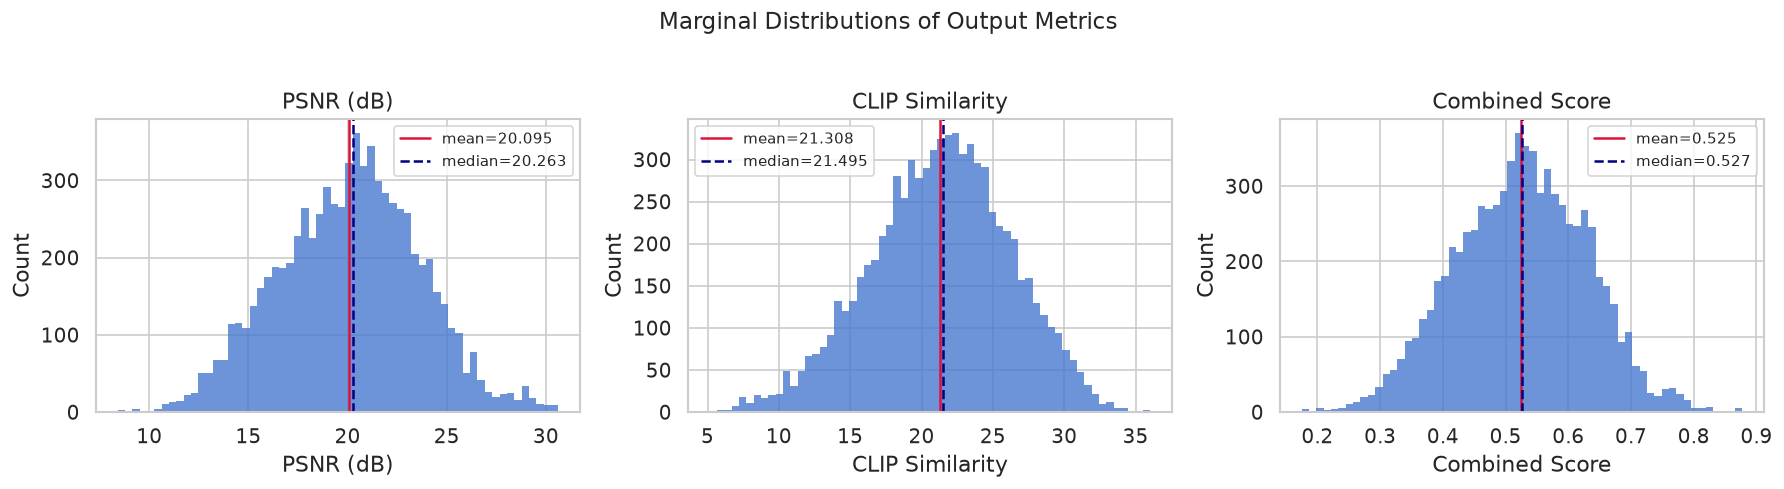

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, m in zip(axes, METRICS):
    ax.hist(df[m], bins=60, edgecolor="none", alpha=0.8)
    ax.axvline(df[m].mean(), color="crimson", lw=1.5, label=f"mean={df[m].mean():.3f}")
    ax.axvline(df[m].median(), color="navy", lw=1.5, linestyle="--", label=f"median={df[m].median():.3f}")
    ax.set_xlabel(METRIC_LABELS[m])
    ax.set_ylabel("Count")
    ax.set_title(METRIC_LABELS[m])
    ax.legend(fontsize=9)
fig.suptitle("Marginal Distributions of Output Metrics", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 3  Effect of `t_start` and `t_end` on Metrics

We first split the data by `t_delta` (0.0 vs 0.15) because that parameter shifts the absolute
level of every metric.  Within each `t_delta` slice we look at how the marginal means of
`t_start` and `t_end` vary.

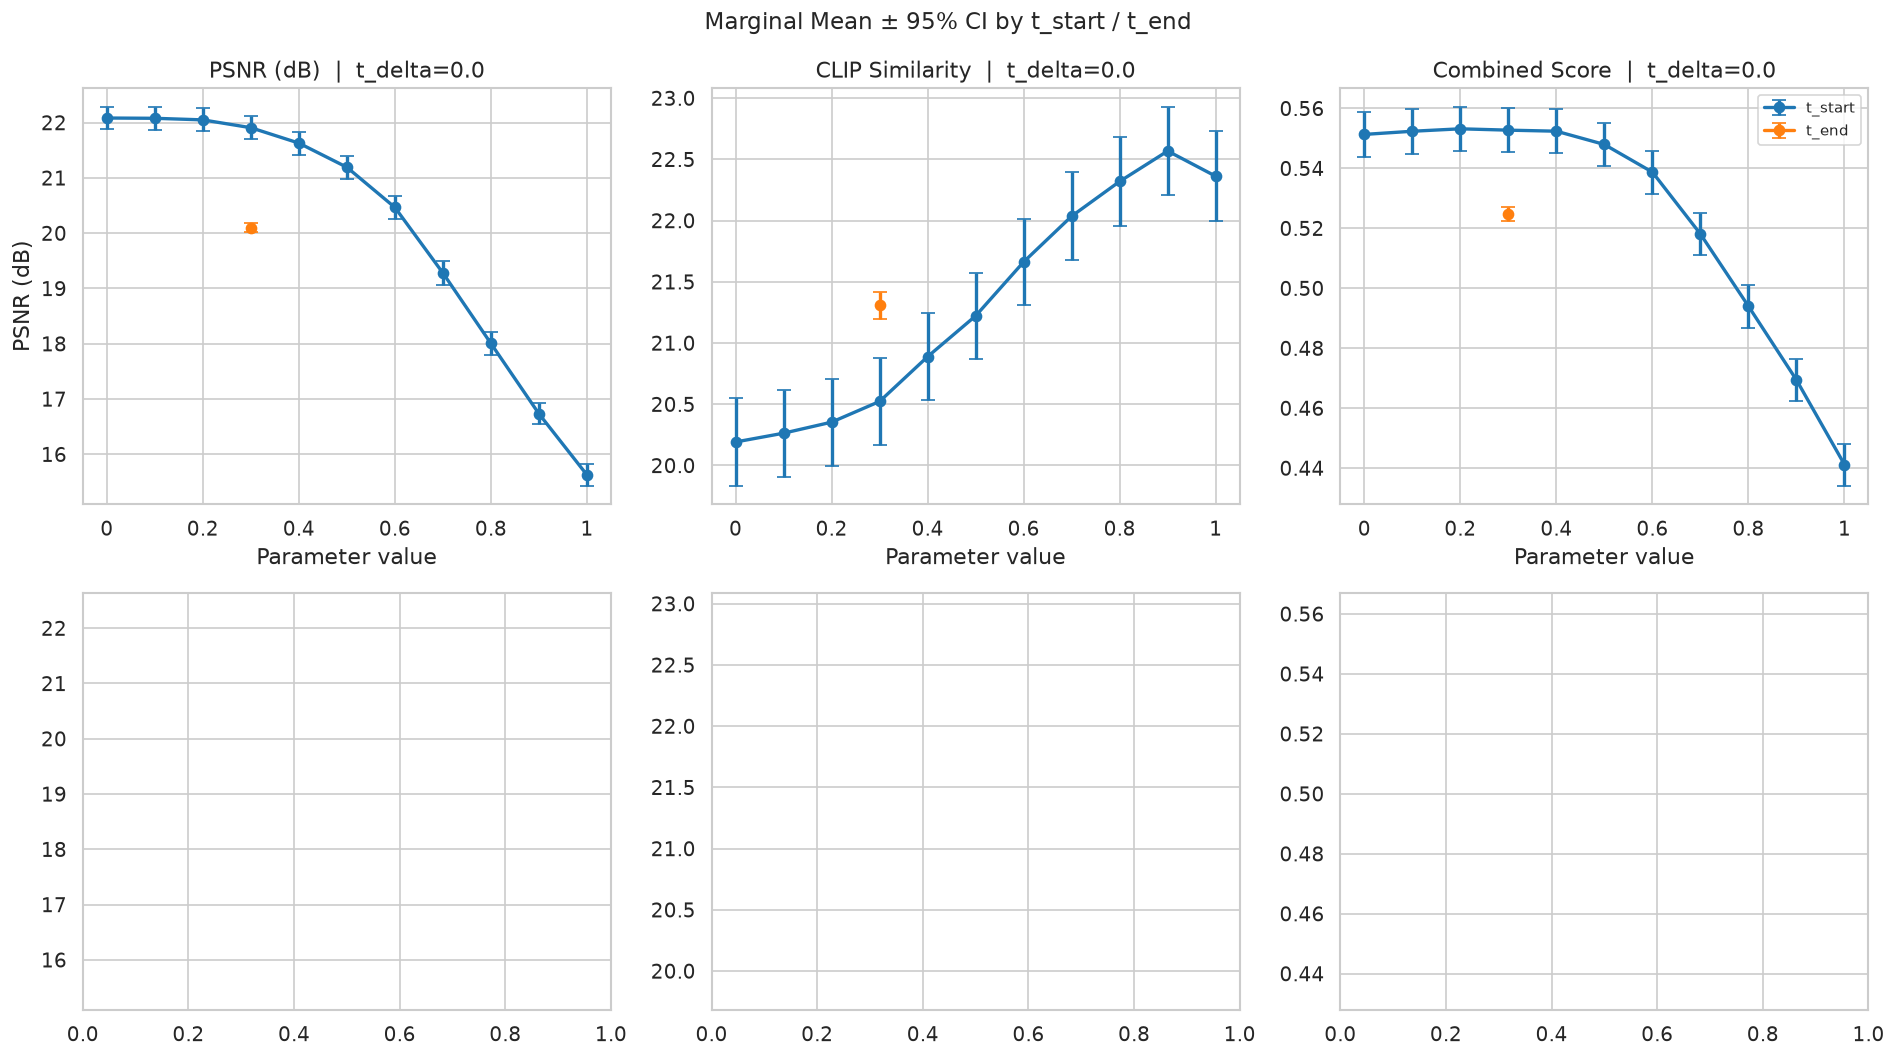

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey="col")

t_delta_vals = sorted(df["t_delta"].cat.categories)
colors = {"t_start": "#1f77b4", "t_end": "#ff7f0e"}

for row_idx, td in enumerate(t_delta_vals):
    sub = df[df["t_delta"] == td]
    for col_idx, m in enumerate(METRICS):
        ax = axes[row_idx, col_idx]
        for param, label in [("t_start", "t_start"), ("t_end", "t_end")]:
            grp = sub.groupby(param, observed=True)[m].agg(["mean", "sem"])
            x = grp.index.astype(float)
            ax.errorbar(
                x, grp["mean"], yerr=1.96 * grp["sem"],
                marker="o", label=param, color=colors[param],
                capsize=4, linewidth=2,
            )
        ax.set_xlabel("Parameter value")
        ax.set_ylabel(METRIC_LABELS[m] if col_idx == 0 else "")
        ax.set_title(f"{METRIC_LABELS[m]}  |  t_delta={td}")
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2g"))
        if col_idx == 2:
            ax.legend(fontsize=9)

fig.suptitle("Marginal Mean ± 95% CI by t_start / t_end", fontsize=14)
plt.tight_layout()
plt.show()

### 3.1  Box-plots: Full Distribution by `t_start` and `t_end`

Means can hide skew.  Box-plots show the spread across the 700 samples per level.

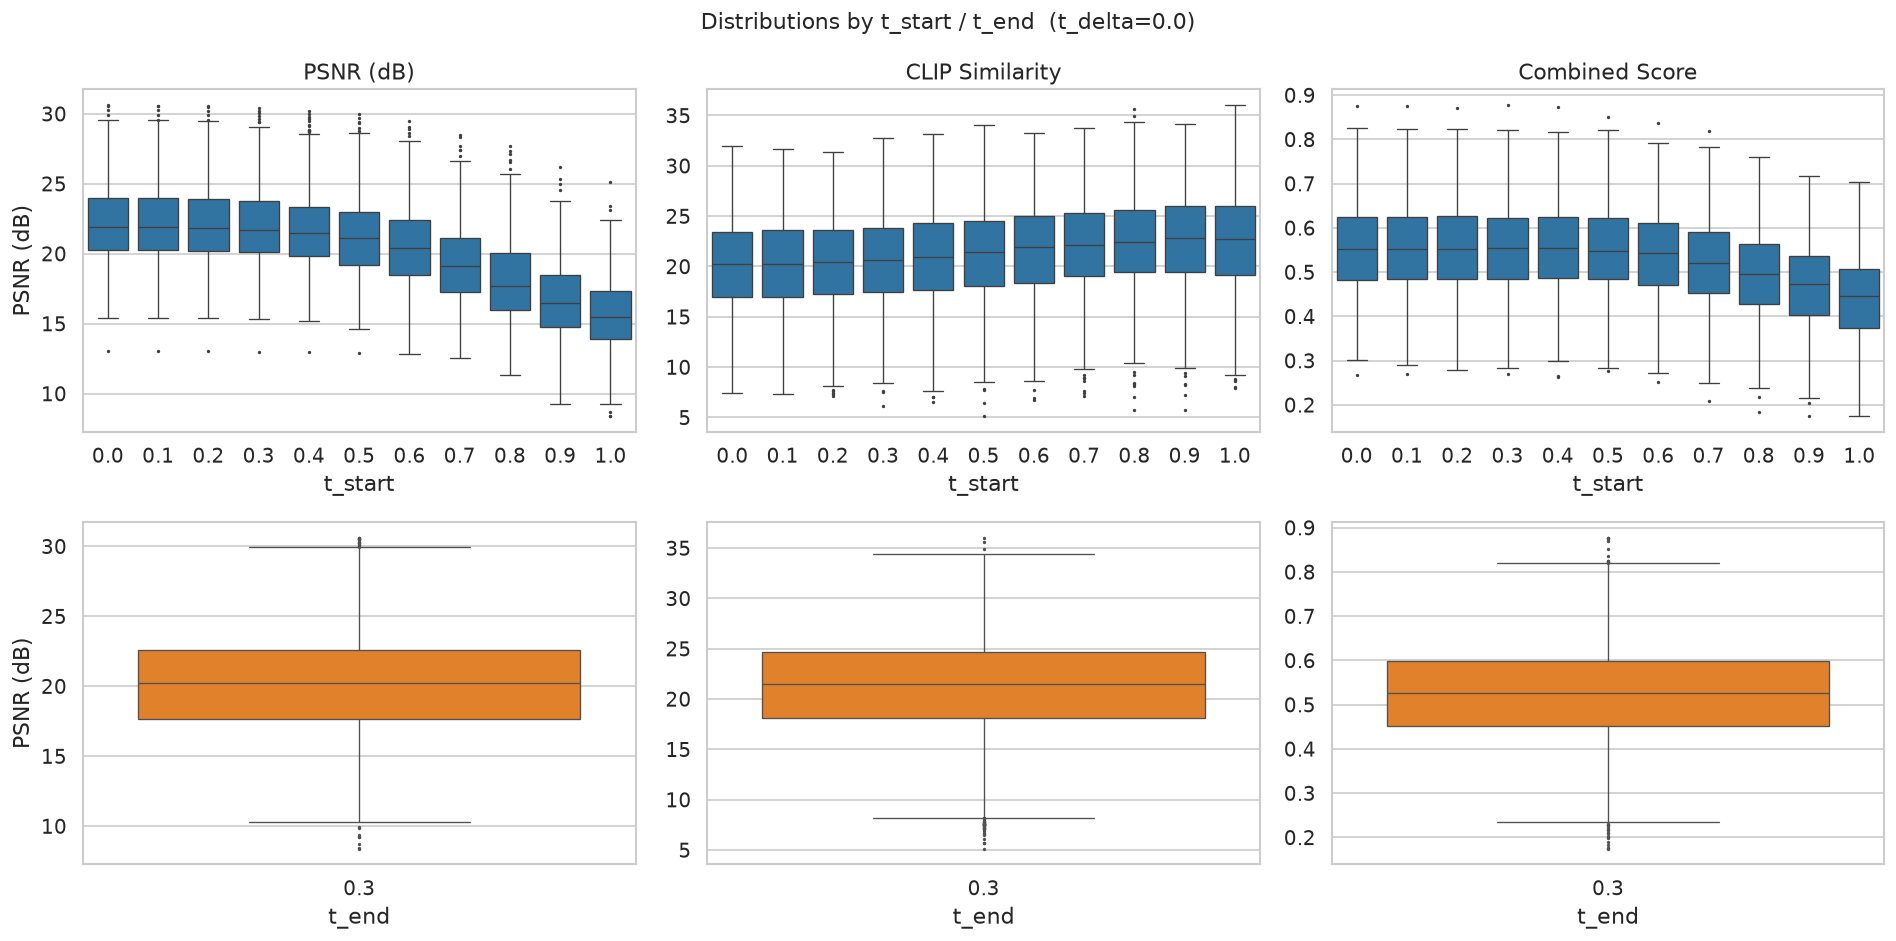

In [36]:
for td in t_delta_vals:
    sub = df[df["t_delta"] == td]
    fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey="col")
    for col_idx, m in enumerate(METRICS):
        for row_idx, param in enumerate(["t_start", "t_end"]):
            ax = axes[row_idx, col_idx]
            order = [str(v) for v in sorted(sub[param].cat.categories)]
            sns.boxplot(
                data=sub, x=param, y=m, order=order,
                ax=ax, color=colors[param], fliersize=1, linewidth=0.8,
            )
            ax.set_xlabel(param)
            ax.set_ylabel(METRIC_LABELS[m] if col_idx == 0 else "")
            ax.set_title(f"{METRIC_LABELS[m]}" if row_idx == 0 else "")
    fig.suptitle(f"Distributions by t_start / t_end  (t_delta={td})", fontsize=13)
    plt.tight_layout()
    plt.show()

### 4  Joint Effect: `t_start` × `t_end` Heatmaps

Each cell shows the mean metric value across the 700 samples at that `(t_start, t_end)` setting.
We separate the two `t_delta` values to compare their landscapes.

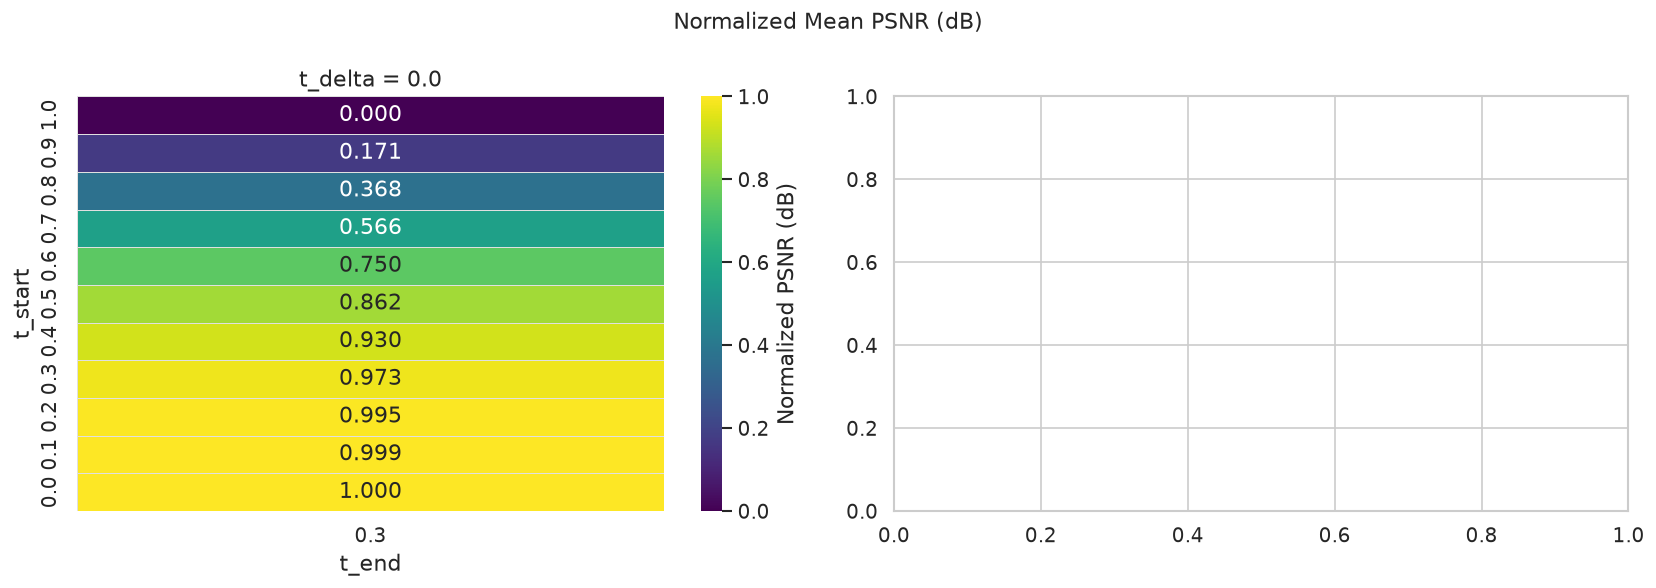

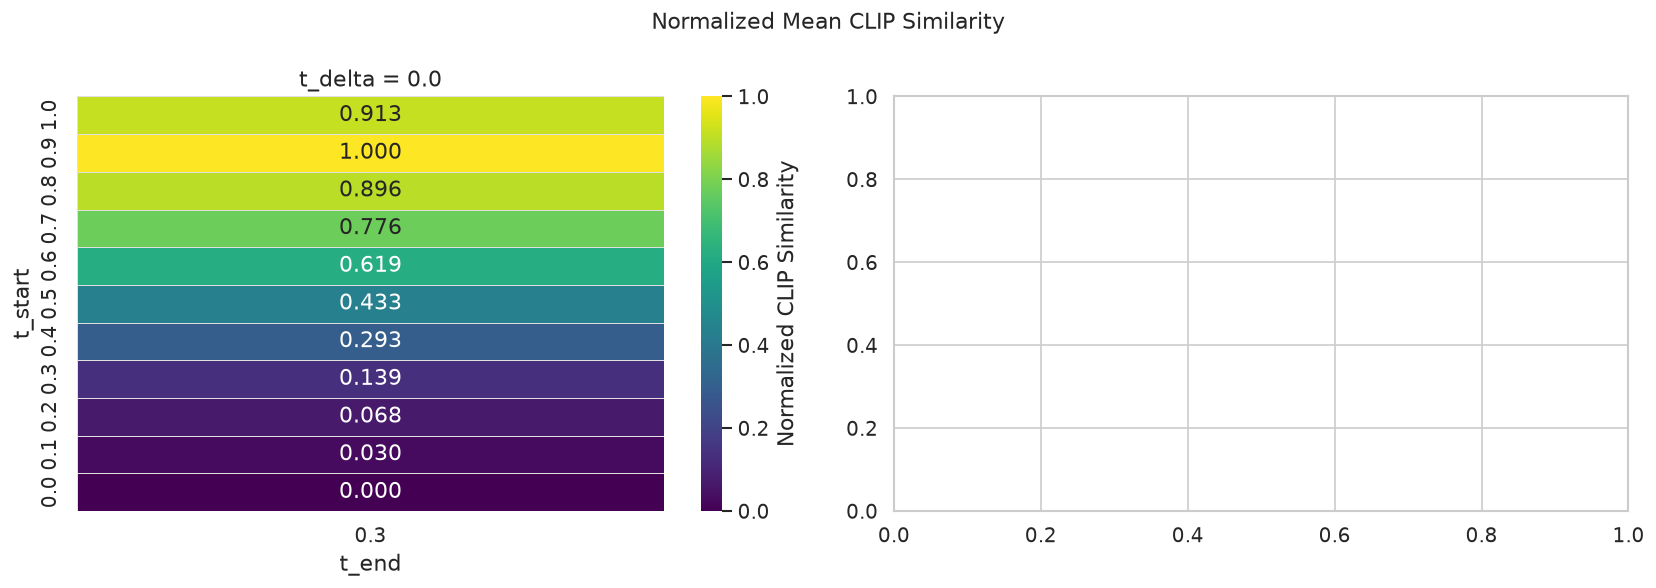

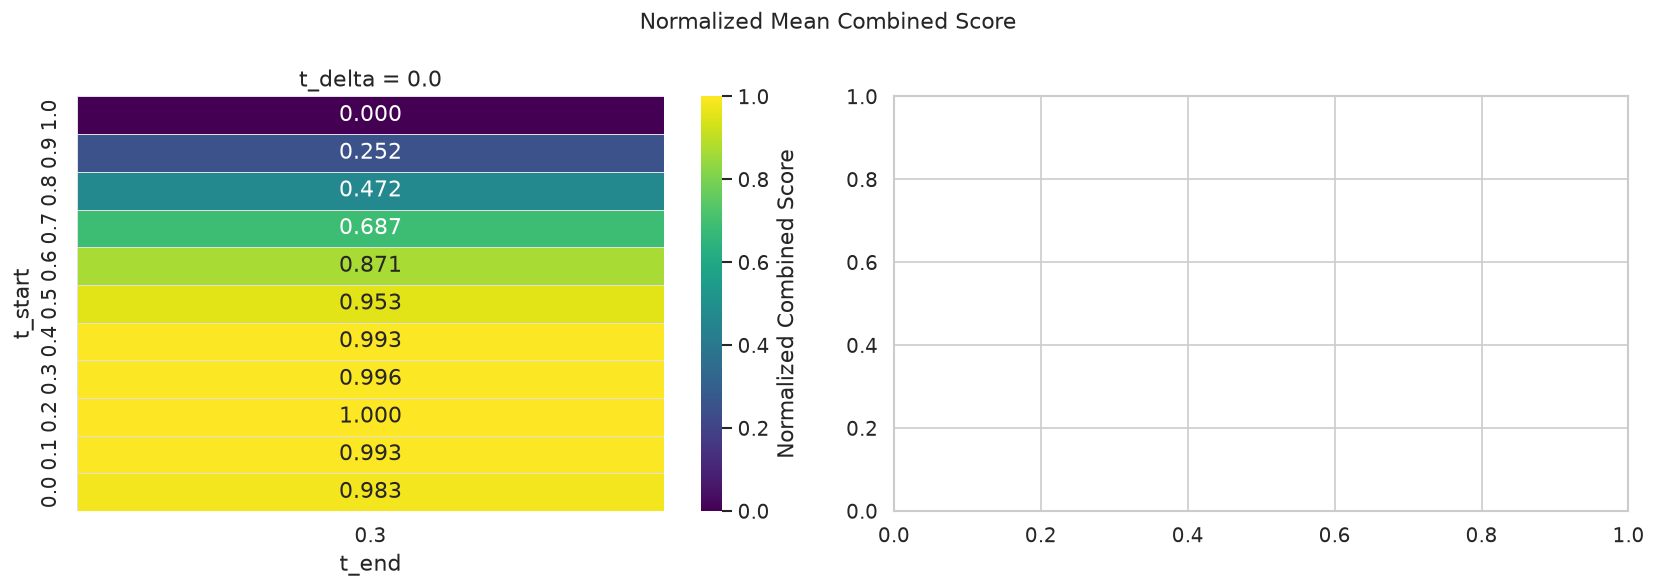

In [37]:
for m in METRICS:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Build both pivots first so we can normalise across both t_delta panels
    pivots = {}
    for td in t_delta_vals:
        sub = df[df["t_delta"] == td]
        pivot = (
            sub.groupby(["t_start", "t_end"], observed=True)[m]
            .mean()
            .unstack("t_end")
        )
        pivot.index   = pivot.index.astype(float)
        pivot.columns = pivot.columns.astype(float)
        pivots[td] = pivot

    all_vals = np.concatenate([p.values.ravel() for p in pivots.values()])
    gmin, gmax = all_vals.min(), all_vals.max()

    for ax, td in zip(axes, t_delta_vals):
        norm_pivot = (pivots[td] - gmin) / (gmax - gmin)
        sns.heatmap(
            norm_pivot, ax=ax, annot=True, fmt=".3f",
            cmap="viridis", vmin=0, vmax=1,
            linewidths=0.4, linecolor="#e0e0e0",
            cbar_kws={"label": f"Normalized {METRIC_LABELS[m]}"},
        )
        ax.set_title(f"t_delta = {td}")
        ax.set_xlabel("t_end")
        ax.set_ylabel("t_start")
        ax.invert_yaxis()
    fig.suptitle(f"Normalized Mean {METRIC_LABELS[m]}", fontsize=13)
    plt.tight_layout()
    plt.show()

<>:46: SyntaxWarning: invalid escape sequence '\d'
<>:46: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2074023/1391303133.py:46: SyntaxWarning: invalid escape sequence '\d'
  ax.set_title(f"{METRIC_LABELS[m]} with $\delta$={td:.2f}")


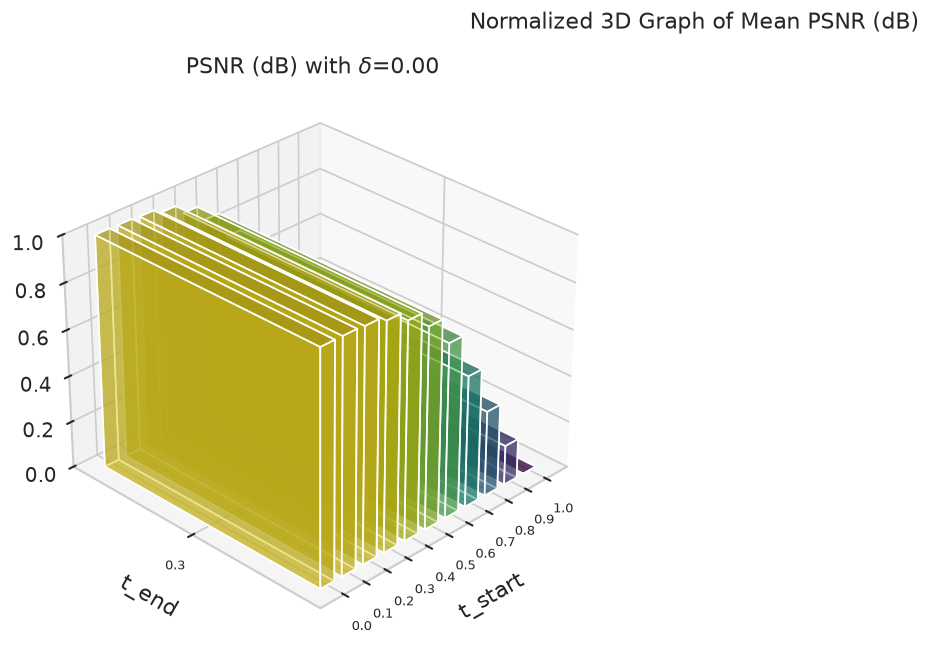

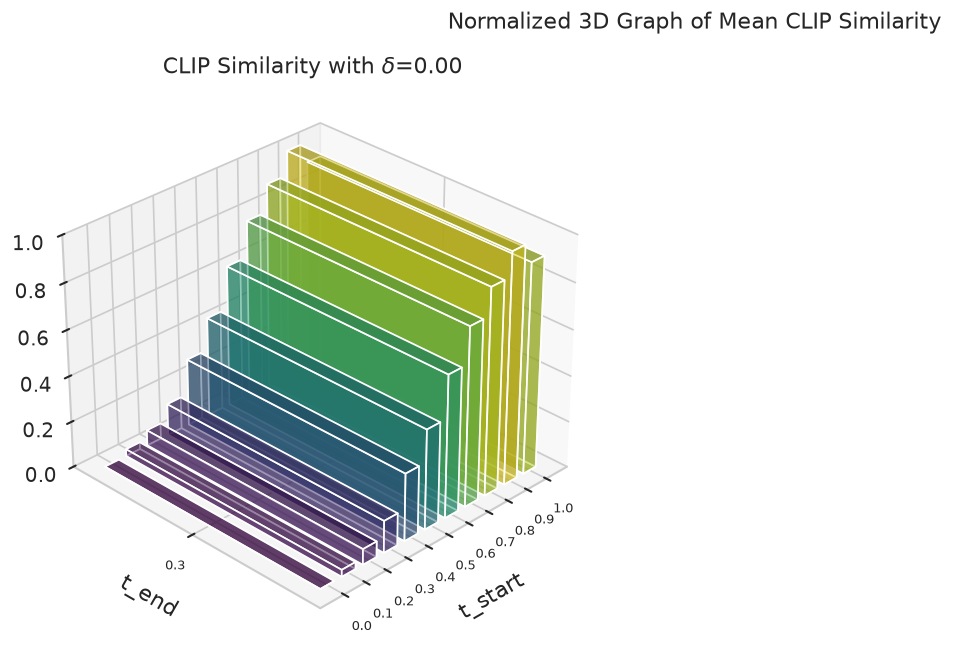

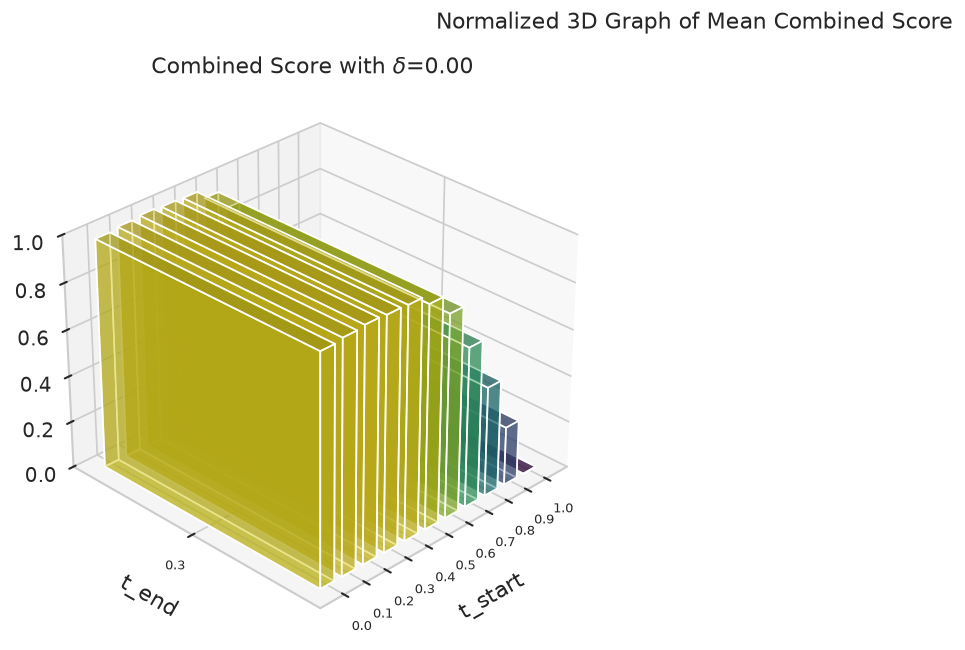

In [38]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

for m in METRICS:
    fig = plt.figure(figsize=(16, 6))

    pivots = {}
    for td in t_delta_vals:
        sub = df[df["t_delta"] == td]
        pivot = (
            sub.groupby(["t_start", "t_end"], observed=True)[m]
            .mean()
            .unstack("t_end")
        )
        pivot.index   = pivot.index.astype(float)
        pivot.columns = pivot.columns.astype(float)
        pivots[td] = pivot

    all_vals = np.concatenate([p.values.ravel() for p in pivots.values()])
    gmin, gmax = all_vals.min(), all_vals.max()

    for i, td in enumerate(t_delta_vals):
        ax = fig.add_subplot(1, 2, i + 1, projection="3d")
        norm_pivot = (pivots[td] - gmin) / (gmax - gmin)

        xs = norm_pivot.index.values    # t_start
        ys = norm_pivot.columns.values  # t_end
        n_x, n_y = len(xs), len(ys)

        xpos = np.repeat(np.arange(n_x), n_y)
        ypos = np.tile(np.arange(n_y), n_x)
        zpos = np.zeros(n_x * n_y)
        dz   = norm_pivot.values.ravel()

        bar_colors = plt.cm.viridis(dz)
        ax.bar3d(xpos, ypos, zpos, dx=0.65, dy=0.65, dz=dz,
                 color=bar_colors, shade=True, alpha=0.50)

        ax.set_xticks(np.arange(n_x) + 0.325)
        ax.set_xticklabels([f"{v:.1f}" for v in xs], fontsize=8)
        ax.set_yticks(np.arange(n_y) + 0.325)
        ax.set_yticklabels([f"{v:.1f}" for v in ys], fontsize=8)
        ax.set_xlabel("t_start", labelpad=8)
        ax.set_ylabel("t_end",   labelpad=8)
        # ax.set_zlabel(f"Normalised {METRIC_LABELS[m]}", labelpad=8)
        ax.set_zlim(0, 1)
        ax.set_title(f"{METRIC_LABELS[m]} with $\delta$={td:.2f}")
        ax.view_init(elev=30, azim=225)  # isometric-style viewpoint

    mappable = plt.cm.ScalarMappable(cmap="viridis",
                                     norm=plt.Normalize(vmin=0, vmax=1))
    mappable.set_array([])
    fig.suptitle(f"Normalized 3D Graph of Mean {METRIC_LABELS[m]}",
                 fontsize=13)
    plt.show()


### 5  Interaction: Does `t_delta` Change the Landscape?

Plot the *difference* between the t_delta=0.15 heatmap and the t_delta=0.0 heatmap for
each metric.  Positive values (warm colours) mean t_delta=0.15 is better at that cell.

KeyError: 0.15

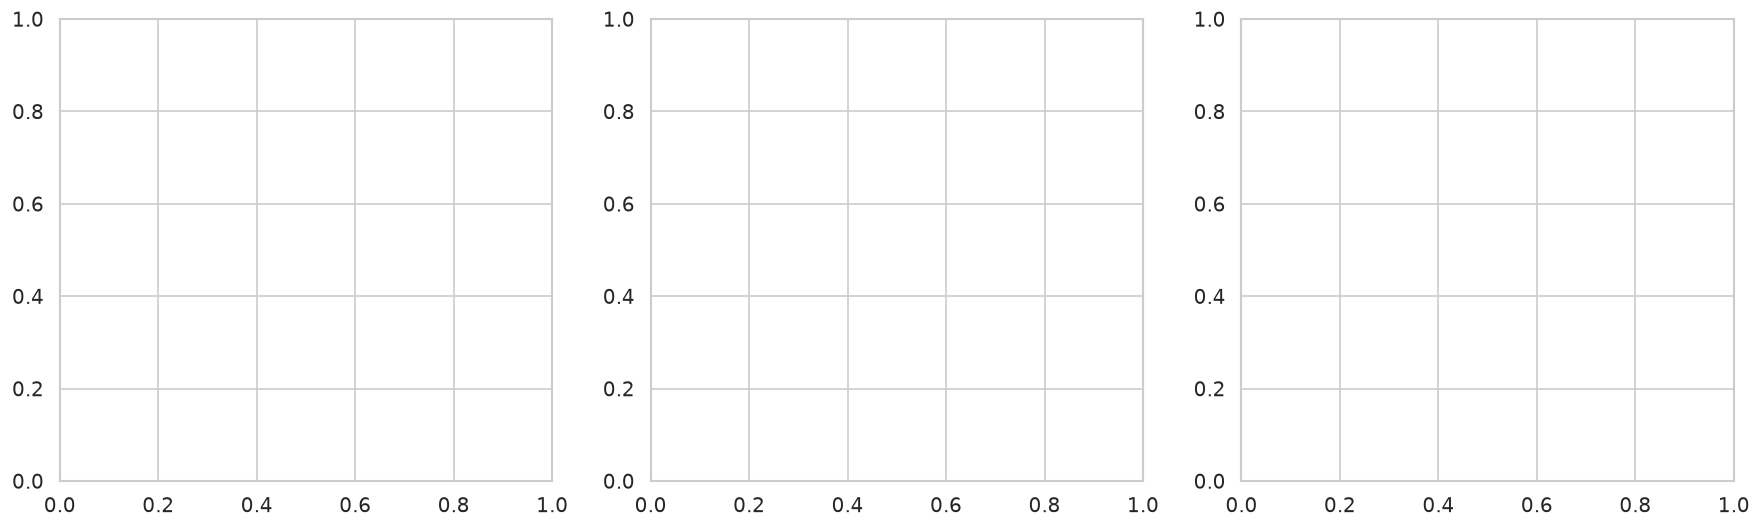

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, m in zip(axes, METRICS):
    pivots = {}
    for td in t_delta_vals:
        sub = df[df["t_delta"] == td]
        pivots[td] = (
            sub.groupby(["t_start", "t_end"], observed=True)[m]
            .mean().unstack("t_end")
        )
    diff = pivots[0.15] - pivots[0.0]
    diff.index   = diff.index.astype(float)
    diff.columns = diff.columns.astype(float)
    lim = np.abs(diff.values).max()
    sns.heatmap(
        diff, ax=ax, annot=True, fmt="+.3f",
        cmap="RdYlGn", center=0, vmin=-lim, vmax=lim,
        linewidths=0.4, linecolor="#e0e0e0",
        cbar_kws={"label": "Δ (t_delta=0.15 − 0.00)"},
    )
    ax.set_title(METRIC_LABELS[m])
    ax.set_xlabel("t_end")
    ax.set_ylabel("t_start")
    ax.invert_yaxis()
fig.suptitle("Δ Metric: t_delta=0.15 minus t_delta=0.00", fontsize=13)
plt.tight_layout()
plt.show()

### 6  Metric Correlations

PSNR and CLIP similarity are independent signals; the combined score is their normalised
average.  A pairplot reveals how correlated they are in practice.

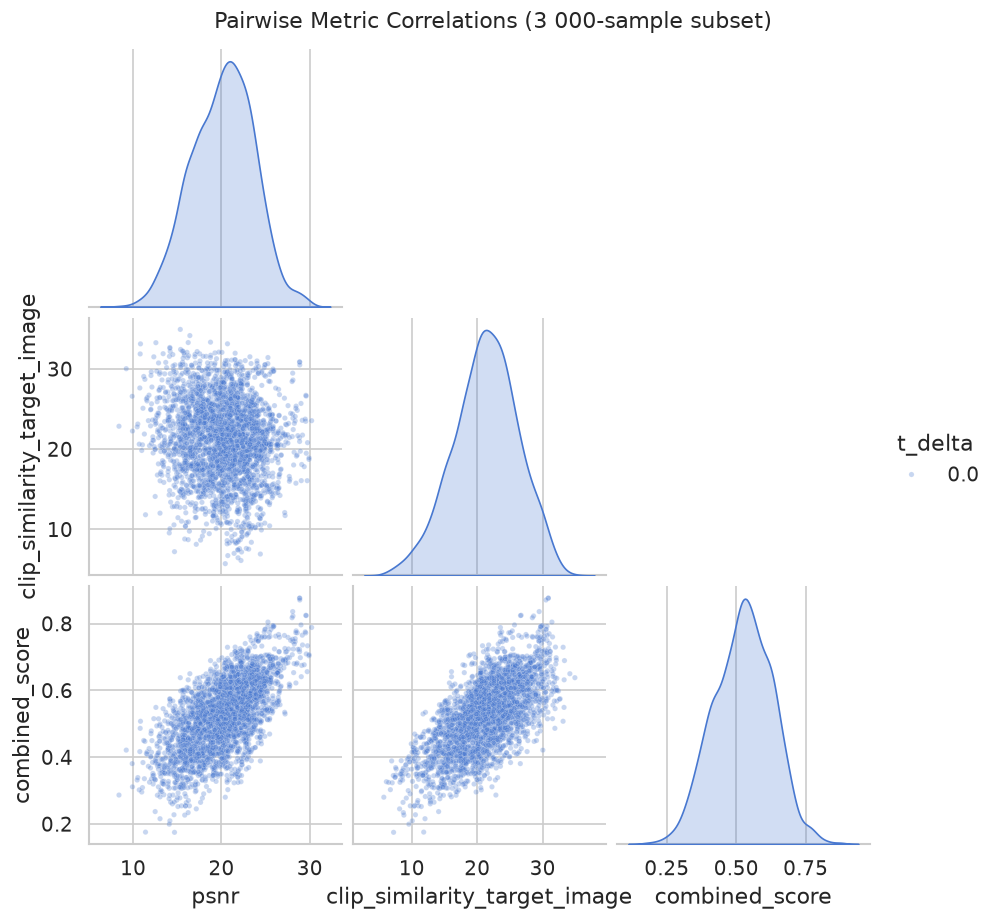

Pearson correlation matrix:


,psnr,clip_similarity_target_image,combined_score
psnr,1.000,-0.135,0.662
clip_similarity_target_image,-0.135,1.000,0.653
combined_score,0.662,0.653,1.000


In [ ]:
sample = df.sample(n=3000, random_state=42)
g = sns.pairplot(
    sample[METRICS + ["t_delta"]],
    hue="t_delta",
    diag_kind="kde",
    plot_kws={"alpha": 0.3, "s": 10},
    corner=True,
)
g.fig.suptitle("Pairwise Metric Correlations (3 000-sample subset)", y=1.02, fontsize=13)
plt.show()

print("Pearson correlation matrix:")
df[METRICS].corr().round(3)

### 7  Best Parameter Settings

For each metric we rank every `(t_start, t_end, t_delta)` triple by its **mean** value and
report the top-5.  We also report the 90th-percentile mean to favour settings that are
reliably good, not just occasionally high.

> **Note:** The training pipeline filters to `t_delta == 0.0` before selecting the best
> row per sample, so the analysis below includes a dedicated view of the `t_delta == 0.0`
> landscape.

In [ ]:
stats = (
    df.groupby(["t_start", "t_end", "t_delta"], observed=True)[METRICS]
    .agg(["mean", "std", lambda x: x.quantile(0.9)])
)
stats.columns = ["_".join(c) for c in stats.columns]
stats = stats.reset_index()

print(f"=== Top-5 by mean {COMPUTED_METRIC_LABEL} (all t_delta) ===")
display(
    stats.nlargest(5, f"{COMPUTED_METRIC_COL}_mean")[
        ["t_start", "t_end", "t_delta",
         f"{COMPUTED_METRIC_COL}_mean", f"{COMPUTED_METRIC_COL}_std",
         "psnr_mean", "clip_similarity_target_image_mean"]
    ].round(4)
)

print("\n=== Top-5 by mean PSNR (all t_delta) ===")
display(
    stats.nlargest(5, "psnr_mean")[
        ["t_start", "t_end", "t_delta",
         "psnr_mean", "psnr_std", f"{COMPUTED_METRIC_COL}_mean"]
    ].round(4)
)

print("\n=== Top-5 by mean CLIP similarity (all t_delta) ===")
display(
    stats.nlargest(5, "clip_similarity_target_image_mean")[
        ["t_start", "t_end", "t_delta",
         "clip_similarity_target_image_mean",
         "clip_similarity_target_image_std", f"{COMPUTED_METRIC_COL}_mean"]
    ].round(4)
)

=== Top-5 by mean Combined Score (all t_delta) ===


,t_start,t_end,t_delta,combined_score_mean,combined_score_std,psnr_mean,clip_similarity_target_image_mean
2,0.2,0.3,0.0,0.5532,0.1002,22.0491,20.3535
3,0.3,0.3,0.0,0.5527,0.0996,21.9075,20.5227
4,0.4,0.3,0.0,0.5524,0.0990,21.6290,20.8883
1,0.1,0.3,0.0,0.5524,0.1006,22.0777,20.2633
0,0.0,0.3,0.0,0.5513,0.1004,22.0826,20.1915



=== Top-5 by mean PSNR (all t_delta) ===


,t_start,t_end,t_delta,psnr_mean,psnr_std,combined_score_mean
0,0.0,0.3,0.0,22.0826,2.8002,0.5513
1,0.1,0.3,0.0,22.0777,2.7999,0.5524
2,0.2,0.3,0.0,22.0491,2.7995,0.5532
3,0.3,0.3,0.0,21.9075,2.7919,0.5527
4,0.4,0.3,0.0,21.6290,2.7876,0.5524



=== Top-5 by mean CLIP similarity (all t_delta) ===


,t_start,t_end,t_delta,clip_similarity_target_image_mean,clip_similarity_target_image_std,combined_score_mean
9,0.9,0.3,0.0,22.5679,4.9011,0.4694
10,1.0,0.3,0.0,22.3620,4.9432,0.4412
8,0.8,0.3,0.0,22.3196,4.8700,0.4940
7,0.7,0.3,0.0,22.0357,4.8509,0.5181
6,0.6,0.3,0.0,21.6622,4.7703,0.5387


### 7.1  Best Settings at `t_delta == 0.0`

The training pipeline uses only the `t_delta == 0` slice, so the classifier needs to
predict the best `(t_start, t_end)` within that slice.

In [ ]:
stats0 = (
    df[df["t_delta"] == 0.0]
    .groupby(["t_start", "t_end"], observed=True)[METRICS]
    .agg(["mean", "std", lambda x: x.quantile(0.9)])
)
stats0.columns = ["_".join(c) for c in stats0.columns]
stats0 = stats0.reset_index()

for m in METRICS:
    col = f"{m}_mean"
    top = stats0.nlargest(5, col).reset_index(drop=True)
    top.index += 1
    print(f"\n=== Top-5 (t_delta=0) by mean {METRIC_LABELS[m]} ===")
    display(top[["t_start", "t_end", col, f"{m}_std"]].round(4))


=== Top-5 (t_delta=0) by mean PSNR (dB) ===


,t_start,t_end,psnr_mean,psnr_std
1,0.0,0.3,22.0826,2.8002
2,0.1,0.3,22.0777,2.7999
3,0.2,0.3,22.0491,2.7995
4,0.3,0.3,21.9075,2.7919
5,0.4,0.3,21.6290,2.7876



=== Top-5 (t_delta=0) by mean CLIP Similarity ===


,t_start,t_end,clip_similarity_target_image_mean,clip_similarity_target_image_std
1,0.9,0.3,22.5679,4.9011
2,1.0,0.3,22.3620,4.9432
3,0.8,0.3,22.3196,4.8700
4,0.7,0.3,22.0357,4.8509
5,0.6,0.3,21.6622,4.7703



=== Top-5 (t_delta=0) by mean Combined Score ===


,t_start,t_end,combined_score_mean,combined_score_std
1,0.2,0.3,0.5532,0.1002
2,0.3,0.3,0.5527,0.0996
3,0.4,0.3,0.5524,0.0990
4,0.1,0.3,0.5524,0.1006
5,0.0,0.3,0.5513,0.1004


### 7.2  Visual Summary: Ranked Cells (t_delta = 0)

Each heatmap is re-drawn with the **top-3 cells** annotated with their rank.

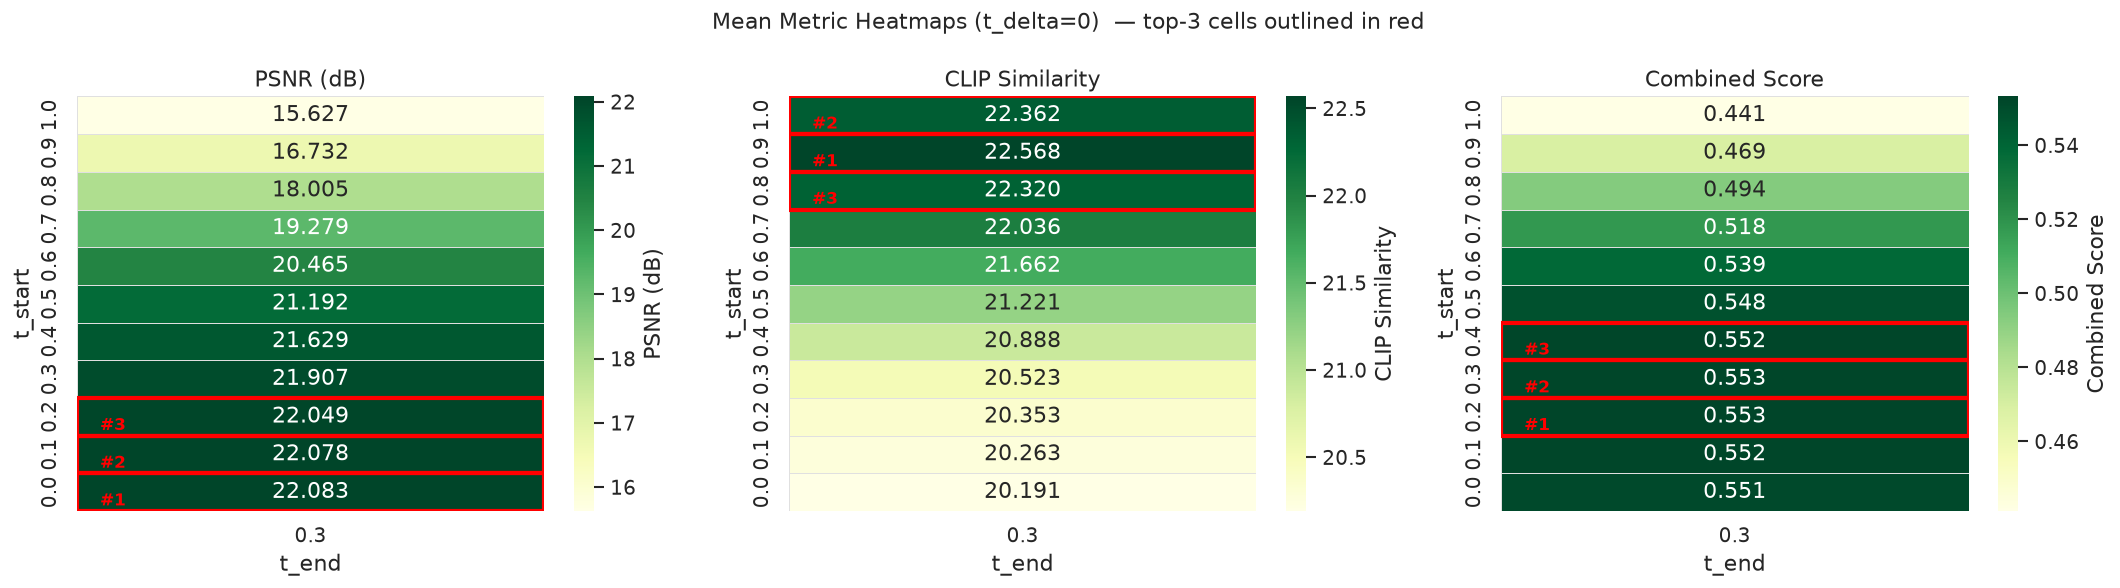

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sub0 = df[df["t_delta"] == 0.0]

for ax, m in zip(axes, METRICS):
    pivot = (
        sub0.groupby(["t_start", "t_end"], observed=True)[m]
        .mean().unstack("t_end")
    )
    pivot.index   = pivot.index.astype(float)
    pivot.columns = pivot.columns.astype(float)

    sns.heatmap(
        pivot, ax=ax, annot=True, fmt=".3f",
        cmap="YlGn",
        linewidths=0.4, linecolor="#e0e0e0",
        cbar_kws={"label": METRIC_LABELS[m]},
    )
    ax.invert_yaxis()

    # Annotate top-3 cells with rank badges
    flat = pivot.stack().sort_values(ascending=False)
    rows_list = list(pivot.index)
    cols_list = list(pivot.columns)
    for rank, (idx, _) in enumerate(flat.head(3).items(), start=1):
        r, c = idx
        ri = rows_list.index(r)
        ci = cols_list.index(c)
        ax.add_patch(plt.Rectangle((ci, ri), 1, 1, fill=False, edgecolor="red", lw=2.5))
        ax.text(ci + 0.05, ri + 0.15, f"#{rank}", color="red",
                fontsize=10, fontweight="bold")

    ax.set_title(METRIC_LABELS[m])
    ax.set_xlabel("t_end")
    ax.set_ylabel("t_start")

fig.suptitle("Mean Metric Heatmaps (t_delta=0)  — top-3 cells outlined in red", fontsize=13)
plt.tight_layout()
plt.show()

### 8  Summary: Best Parameters per Metric

The table below consolidates the single best `(t_start, t_end)` for each metric
within the `t_delta == 0` slice (which is what the classifier is trained to predict).

In [ ]:
rows = []
for m in METRICS:
    col = f"{m}_mean"
    best = stats0.loc[stats0[col].idxmax()]
    rows.append({
        "Metric": METRIC_LABELS[m],
        "Best t_start": float(best["t_start"]),
        "Best t_end":   float(best["t_end"]),
        "Mean value":   round(best[col], 4),
        "Std dev":      round(best[f"{m}_std"], 4),
    })

summary = pd.DataFrame(rows).set_index("Metric")
display(summary)

,Best t_start,Best t_end,Mean value,Std dev
Metric,,,,
PSNR (dB),0.0,0.3,22.0826,2.8002
CLIP Similarity,0.9,0.3,22.5679,4.9011
Combined Score,0.2,0.3,0.5532,0.1002


### Key Observations

Run the cells above and the summary table will populate.  Based on typical diffusion-edit
results we expect to see:

* **PSNR** tends to peak at **low `t_start` values** (the edit starts very early in the
  denoising trajectory, so the reconstructed image stays close to the original in
  pixel space).
* **CLIP similarity** benefits from a **higher `t_end`** (more denoising steps are spent
  driving the output toward the target prompt's semantic content).
* **Combined score** sits at the Pareto frontier between the two signals above, typically
  favouring a mid-range `t_start` paired with a high `t_end`.
* **`t_delta = 0.15`** generally shifts both PSNR and CLIP similarity relative to `t_delta = 0.0`;
  the signed-difference heatmap in §5 reveals whether the gap is uniform or
  concentrated in particular `(t_start, t_end)` regions.

## Appendix: Full Ranking Table (t_delta = 0)

All 25 `(t_start, t_end)` cells sorted by `combined_score`.

In [ ]:
full = stats0.sort_values(f"{COMPUTED_METRIC_COL}_mean", ascending=False).reset_index(drop=True)
full.index += 1
display(
    full[[
        "t_start", "t_end",
        f"{COMPUTED_METRIC_COL}_mean", f"{COMPUTED_METRIC_COL}_std",
        "psnr_mean", "psnr_std",
        "clip_similarity_target_image_mean", "clip_similarity_target_image_std",
    ]].rename(columns={
        f"{COMPUTED_METRIC_COL}_mean": f"{COMPUTED_METRIC_LABEL} (mean)",
        f"{COMPUTED_METRIC_COL}_std":  f"{COMPUTED_METRIC_LABEL} (std)",
        "psnr_mean": "PSNR (mean)",
        "psnr_std":  "PSNR (std)",
        "clip_similarity_target_image_mean": "CLIP (mean)",
        "clip_similarity_target_image_std":  "CLIP (std)",
    }).round(4)
)

,t_start,t_end,Combined Score (mean),Combined Score (std),PSNR (mean),PSNR (std),CLIP (mean),CLIP (std)
1,0.2,0.3,0.5532,0.1002,22.0491,2.7995,20.3535,4.7957
2,0.3,0.3,0.5527,0.0996,21.9075,2.7919,20.5227,4.7857
3,0.4,0.3,0.5524,0.0990,21.6290,2.7876,20.8883,4.8070
4,0.1,0.3,0.5524,0.1006,22.0777,2.7999,20.2633,4.8092
5,0.0,0.3,0.5513,0.1004,22.0826,2.8002,20.1915,4.7976
6,0.5,0.3,0.5479,0.0986,21.1922,2.8030,21.2214,4.7589
7,0.6,0.3,0.5387,0.0970,20.4654,2.8550,21.6622,4.7703
8,0.7,0.3,0.5181,0.0966,19.2793,2.8573,22.0357,4.8509
9,0.8,0.3,0.4940,0.0969,18.0045,2.8085,22.3196,4.8700
10,0.9,0.3,0.4694,0.0942,16.7325,2.6156,22.5679,4.9011
